In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import yaml, os, copy, time, json

from scipy.stats import poisson, qmc
from scipy.optimize import root_scalar, brentq
from scipy.special import ellipe, ellipk
from mpmath import polylog
from math import comb

from gpt import GPT

from distgen import Generator
from matplotlib.colors import SymLogNorm

from specific_particle_tracer import SpecificParticleTracer, HemisphericalTip, FlatCathode
from specific_particle_tracer.bem.geometry import HemisphericalTipBEMGeometry, CylindricalWellBEMGeometry
from specific_particle_tracer.distributions import flat_distribution_to_hemisphere
from specific_particle_tracer.constants import ELEMENTARY_CHARGE

from specific_particle_tracer.plotting import plot_profiles, static_potential_grid, image_potential_grid

from GPT_tools.tools import get_screen_data
from GPT_tools.gpt_plot import gpt_plot_dist1d, gpt_plot_dist2d
from GPT_tools.image_charge import MakeMetalParticleGroup, MakeSemiconductorParticleGroup, MakeEnergyOffsetParticleGroup
from GPT_tools.image_charge import MTE_model, QE_model, getValueFromSettings, getSemiconductorEexc

template_dir = r'C:\Users\acb20\OneDrive\Desktop\Claude\BEM\distgen'
DISTGEN_INPUT_FILE = os.path.join(template_dir,'distgen.in.yaml')

# ---------------------------------------------------------------------
# Settings for multi-threading

max_workers = 8   # number of threads on your computer

In [2]:
# Some font size defaults
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Liberation Sans', 'DejaVu Sans'],
    'mathtext.fontset': 'dejavusans',
    'axes.labelsize': 18,
    'axes.titlesize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 14,
})

In [3]:
# Some plotting functions

def M_from_C(C):
    return C / np.sum(C, axis=1, keepdims=True)

def counts_from_C(C):
    return np.sum(C, axis=1)

def truncate_C(C):
    row_is_done = np.any(C != 0, axis=1)
    rows_done = np.where(row_is_done)[0]
    if (len(rows_done) == 0):
        return C[0:0, 0:0]
    N = np.max(rows_done) + 1
    return C[:N, :N]
    
def get_fano_curve(M, lambda_list):

    initial_n = np.arange(M.shape[0])
    final_m = np.arange(M.shape[1])

    Bi = M @ final_m
    Ci = M @ (final_m**2)

    Pi = poisson.pmf(initial_n[:,None], lambda_list[None,:])

    avg_n = Bi @ Pi
    avg_n2 = Ci @ Pi

    fano = (avg_n2 - avg_n**2)/avg_n

    return avg_n, fano


def sample_M_dirichlet(C, rng=None):

    if (rng is None):
        rng = np.random.default_rng()

    M_sample = np.zeros_like(C, dtype=float)

    M_sample[0,0] = 1.0

    for ii in np.arange(1, C.shape[0]):

        allowed = np.arange(C.shape[1]) <= ii

        alpha = C[ii,allowed].astype(float)

        M_sample[ii,allowed] = rng.dirichlet(alpha)

    return M_sample

def get_avg_e_max_from_M(M, tail_prob=1e-3):

    max_initial_n = M.shape[0] - 1

    def f(lam):
        return poisson.sf(max_initial_n, lam) - tail_prob

    if (f(0) > 0):
        return 0.0

    lam_hi = max_initial_n

    while (f(lam_hi) < 0):
        lam_hi *= 2

    return brentq(f, 0, lam_hi)

def plot_fano_with_error(C, avg_e_max=None, use_electrons_escaping=True,
                         fig_ax=None, color='r', label='Data',
                         n_trials=50, ci=0.95, rng=None):

    C = truncate_C(C)
    M = M_from_C(C)
    
    if (rng is None):
        rng = np.random.default_rng()

    if (avg_e_max is None):
        avg_e_max = get_avg_e_max_from_M(M)

    lambda_list = np.linspace(0.01, avg_e_max, 300)

    charge_list, fano_list = get_fano_curve(M, lambda_list)

    if (use_electrons_escaping):
        x = charge_list
    else:
        x = lambda_list

    fano_mc = np.zeros((n_trials, len(lambda_list)))

    for kk in np.arange(n_trials):

        M_sample = sample_M_dirichlet(C, rng=rng)
        charge_sample, fano_sample = get_fano_curve(M_sample, lambda_list)

        if (use_electrons_escaping):
            order = np.argsort(charge_sample)
            x_sample = charge_sample[order]
            y_sample = fano_sample[order]

            keep = np.insert(np.diff(x_sample) > 0, 0, True)

            fano_mc[kk,:] = np.interp(x, x_sample[keep], y_sample[keep],
                                      left=np.nan, right=np.nan)
        else:
            fano_mc[kk,:] = fano_sample

    qlo = 50*(1 - ci)
    qhi = 100 - qlo

    fano_lo = np.nanpercentile(fano_mc, qlo, axis=0)
    fano_hi = np.nanpercentile(fano_mc, qhi, axis=0)

    if (fig_ax is None):
        fig, ax = plt.subplots()
    else:
        fig, ax = fig_ax

    ax.fill_between(x, fano_lo, fano_hi, color=color, alpha=0.25, linewidth=0)
    ax.plot(x, fano_list, '-', label=label, color=color)

    ax.set_ylim((0,1))
    ax.set_xlim((0,np.nanmax(x)))

    if (use_electrons_escaping):
        ax.set_xlabel('Average electrons escaping')
    else:
        ax.set_xlabel('Average electrons emitted')

    ax.set_ylabel('Fano Factor')
    ax.legend()

def get_merit_curve(M, lambda_list):

    initial_n = np.arange(M.shape[0])

    p_one = np.zeros(len(lambda_list))
    p_multi = np.zeros(len(lambda_list))

    multi_given_n = np.sum(M[:,2:], axis=1)

    for jj,lam in enumerate(lambda_list):
        p_initial = poisson.pmf(initial_n, lam)

        p_one[jj] = np.sum(p_initial * M[:,1])
        p_multi[jj] = np.sum(p_initial * multi_given_n)

    return p_multi, p_one

def plot_merit(C, avg_e_max=None, fig_ax=None, color='r', label='Data',
               show_poisson=True, xlim=[0.01,1], n_trials=50, ci=0.95,
               rng=None):

    C = truncate_C(C)
    M = M_from_C(C)
    
    if (rng is None):
        rng = np.random.default_rng()

    if (avg_e_max is None):
        avg_e_max = get_avg_e_max_from_M(M)

    lambda_min = 1.0e-4
    lambda_list = np.geomspace(lambda_min, avg_e_max, 500)

    p_multi, p_one = get_merit_curve(M, lambda_list)

    mu_list = np.geomspace(1.0e-4, 20, 1000)

    p_one_ideal = mu_list * np.exp(-mu_list)
    p_multi_ideal = 1 - np.exp(-mu_list) * (1 + mu_list)

    if (fig_ax is None):
        fig, ax = plt.subplots()
    else:
        fig, ax = fig_ax

    if (C is not None):

        p_one_mc = np.zeros((n_trials, len(lambda_list)))

        for kk in np.arange(n_trials):

            M_sample = sample_M_dirichlet(C, rng=rng)

            p_multi_sample, p_one_sample = get_merit_curve(M_sample, lambda_list)

            order = np.argsort(p_multi_sample)

            x_sample = p_multi_sample[order]
            y_sample = p_one_sample[order]

            keep = np.insert(np.diff(x_sample) > 0, 0, True)

            p_one_mc[kk,:] = np.interp(p_multi, x_sample[keep], y_sample[keep],
                                       left=np.nan, right=np.nan)

        qlo = 50*(1 - ci)
        qhi = 100 - qlo

        p_one_lo = np.nanpercentile(p_one_mc, qlo, axis=0)
        p_one_hi = np.nanpercentile(p_one_mc, qhi, axis=0)

        ax.fill_between(p_multi, p_one_lo, p_one_hi,
                        color=color, alpha=0.25, linewidth=0)

    ax.semilogx(
        p_multi,
        p_one,
        color=color,
        label=label
    )

    if (show_poisson):
        ax.semilogx(
            p_multi_ideal,
            p_one_ideal,
            color='k',
            linestyle='--',
            label=r'Poisson'
        )

    ax.set_xlim(xlim)
    ax.set_ylim((0,1))

    ax.set_ylabel(r'$P(N=1)$')
    ax.set_xlabel(r'$P(N>1)$')
    ax.legend()
    

In [4]:
# Run functions

def get_row_rel_err(counts_row):

    N = np.sum(counts_row)

    if (N == 0):
        return np.inf

    max_nonzero_count = np.max(counts_row[1:])

    if (max_nonzero_count == 0):
        return np.inf

    pmax = max_nonzero_count / N

    return np.sqrt((1 - pmax)/(N*pmax))


def get_next_n_runs(counts_row):

    N = int(np.sum(counts_row))

    if (N == 0):
        return n_runs_start

    if (N >= n_runs_max_total):
        return 0

    max_nonzero_count = np.max(counts_row[1:])

    if (max_nonzero_count == 0):
        n_more = np.max([n_runs_min_add, (n_runs_max_times_more - 1)*N])
        return int(np.min([n_more, n_runs_max_total - N]))

    pmax = max_nonzero_count / N
    n_required = int(np.ceil((1 - pmax)/(pmax*rel_accuracy**2)))
    n_more = n_required - N

    if (n_more <= 0):
        return 0

    n_more = np.max([n_runs_min_add, n_more])
    n_more = np.min([(n_runs_max_times_more - 1)*N, n_more])
    n_more = np.min([n_more, n_runs_max_total - N])

    return int(n_more)


def is_done(num_par):
    num_par = int(num_par)
    return ((n_runs_n[num_par] > 0) and
            ((get_row_rel_err(counts_n[num_par,:]) <= rel_accuracy) or
             (n_runs_n[num_par] >= n_runs_max_total)))


def get_values_to_scan():
    return [int(num_par) for num_par in values_to_scan_all if not is_done(num_par)]


def make_initial_particle_group(settings_run, rng=np.random.default_rng()):
    if (settings['cathode_type'] == 'metal'):
        PG_initial = MakeMetalParticleGroup(settings_run, DISTGEN_INPUT_FILE=DISTGEN_INPUT_FILE, verbose=False, only_survivors=settings_run['only_survivors'], rng=rng)
    elif (settings['cathode_type'] == 'semiconductor'):
        PG_initial = MakeSemiconductorParticleGroup(settings_run, DISTGEN_INPUT_FILE=DISTGEN_INPUT_FILE, verbose=False, only_survivors=settings_run['only_survivors'], rng=rng)
    elif (settings['cathode_type'] == 'distgen'):
        if (not settings_run['only_survivors']):
            raise ValueError("ERROR: only_survivors must be used with distgen")
        PG_initial = MakeEnergyOffsetParticleGroup(settings_run, DISTGEN_INPUT_FILE=DISTGEN_INPUT_FILE, verbose=False)
    else:
        raise ValueError("ERROR: bad cathode type")

    PG_initial.weight = ELEMENTARY_CHARGE # Just to make sure, not really needed

    return PG_initial


def get_counts_from_gpt_data(gpt_data, num_par, n_runs_this_batch, settings_run):

    counts_this_batch = np.zeros(max_particles+1)

    if (len(gpt_data.screen) == 0):
        counts_this_batch[0] = n_runs_this_batch
        return counts_this_batch

    last_screen = get_screen_data(gpt_data, screen_z=settings_run['zmax'])[0]

    if (np.abs(last_screen['mean_z'] - settings_run['zmax']) > 1.0e-3*settings_run['zmax']):
        counts_this_batch[0] = n_runs_this_batch
        return counts_this_batch

    which_bunch = np.floor((last_screen.id-1)/num_par).astype(int)
    (vals, n_emit) = np.unique(which_bunch, return_counts=True)

    if (len(vals) == 0):
        counts_this_batch[0] = n_runs_this_batch
        return counts_this_batch

    if (np.min(which_bunch) < 0):
        raise RuntimeError('Bad particle IDs: found bunch index < 0')

    if (np.max(which_bunch) >= n_runs_this_batch):
        raise RuntimeError('Bad particle IDs: found bunch index >= n_runs_this_batch')

    if (np.max(n_emit) > num_par):
        raise RuntimeError('Bad particle IDs: found more survivors than injected particles')

    counts_this_batch[0] = n_runs_this_batch - len(vals)

    (emitted_vals, emitted_counts) = np.unique(n_emit, return_counts=True)
    counts_this_batch[emitted_vals] = emitted_counts

    if (np.sum(counts_this_batch) != n_runs_this_batch):
        raise RuntimeError('Bad emitted-count histogram')

    return counts_this_batch


def append_gpt_data(gpt_data_old, gpt_data_new, id_offset, settings_run):

    if (len(gpt_data_new.particles) == 0):
        return gpt_data_old

    gpt_data_new = copy.deepcopy(gpt_data_new)

    for p in gpt_data_new.particles:
        p.id = p.id + id_offset

    if (gpt_data_old is None):
        return gpt_data_new

    ztol = settings_run['zmax']*1.0e-6

    for p_new in gpt_data_new.particles:

        z_new = p_new['mean_z']
        found_screen = False

        for jj,p_old in enumerate(gpt_data_old.particles):

            if (np.abs(p_old['mean_z'] - z_new) < ztol):
                gpt_data_old.particles[jj] = p_old + p_new
                found_screen = True
                break

        if (not found_screen):
            gpt_data_old.particles.append(p_new)

    return gpt_data_old

## Distgen


In [9]:
settings = {}

# ---------------------------------------------------------------------
# Settings for distgen

settings['random:type'] = 'pseudo'  # 'pseudo' = not Hammersley

settings['r_dist:sigma_xy:value'] = 10.0/4
settings['r_dist:sigma_xy:units'] = 'nm'
settings['r_dist:alpha:value'] = 0  # 0 = flat top, 1 = gaussian

settings['t_dist:sigma_t:value'] = 10
settings['t_dist:sigma_t:units'] = 'fs'
settings['t_dist:alpha:value'] = 0  # 0 = flat top, 1 = gaussian

# ---------------------------------------------------------------------
# Settings for cathode emission model

settings['cathode_type'] = 'semiconductor'  # metal, semiconductor, or distgen
settings['only_survivors'] = False 

settings['effective_mass'] = 0.067

# Metal only settings
if (settings['cathode_type'] == 'metal'):
    settings['photon_energy:value'] = 1.600 # 1.461
    settings['photon_energy:units'] = 'eV'
    
    settings['kT:value'] = 25e-3
    settings['kT:units'] = 'meV'
    
    settings['work_function:value'] = 1.4
    settings['work_function:units'] = 'eV'

# Semiconductor only settings
if (settings['cathode_type'] == 'semiconductor'):
    settings['photon_energy:value'] = 1.500
    settings['photon_energy:units'] = 'eV'
    
    settings['electron_affinity:value'] = -0.0
    settings['electron_affinity:units'] = 'eV'
    
    settings['energy_gap:value'] = 1.4
    settings['energy_gap:units'] = 'eV'

# distgen only settings
if (settings['cathode_type'] == 'distgen'):
    settings['start:MTE:value'] = 25
    settings['start:MTE:units'] = 'meV'

# ---------------------------------------------------------------------
# Settings for GPT

settings['gun_field:value'] = 0.1   # asymptotic field for large r
settings['gun_field:units'] = 'MV/m'

settings['plummer_radius:value'] = 1.0e-3
settings['plummer_radius:units'] = 'nm'

settings['cathode_z_offset:value'] = 3
settings['cathode_z_offset:units'] = 'nm'

settings['tmax'] = 1e-9
settings['zmax'] = 1.1e-6 

# ---------------------------------------------------------------------

settings['cathode_wall'] = 0

# ---------------------------------------------------------------------
# RNG settings
rng = np.random.default_rng()

In [10]:
# ---------------------------------------------------------------------
# Make initial distribution

n_particles = 1e5

verbose=True

# ---------------------------------------------------------------------

settings_copy = copy.copy(settings)
settings_copy['n_particle'] = n_particles

# ---------------------------------------------------------------------

if (settings['cathode_type'] == 'metal'):
    PG_initial = MakeMetalParticleGroup(settings_copy, DISTGEN_INPUT_FILE=DISTGEN_INPUT_FILE, verbose=verbose, only_survivors=settings_copy['only_survivors'], rng=rng)
elif (settings['cathode_type'] == 'semiconductor'):
    PG_initial = MakeSemiconductorParticleGroup(settings_copy, DISTGEN_INPUT_FILE=DISTGEN_INPUT_FILE, verbose=verbose, only_survivors=settings_copy['only_survivors'], rng=rng)
elif (settings['cathode_type'] == 'distgen'):
    if (not settings_copy['only_survivors']):
        raise ValueError("ERROR: only_survivors must be used with distgen")
    PG_initial = MakeEnergyOffsetParticleGroup(settings_copy, DISTGEN_INPUT_FILE=DISTGEN_INPUT_FILE, verbose=verbose)
else:
    raise ValueError("ERROR: bad cathode type")

PG_initial.weight = ELEMENTARY_CHARGE # Just to make sure, not really needed

PG_run = copy.deepcopy(PG_initial)

# ---------------------------------------------------------------------
geometry = FlatCathode(E_gun=-settings_copy["gun_field"], z0=settings_copy["cathode_z_offset"])  # closed-form, for comparison

Adding settings["gun_field"] = 100000.0 for use in GPT
Adding settings["cathode_z_offset"] = 3.0000000000000004e-09 for use in GPT
Adding settings["plummer_radius"] = 1.0000000000000002e-12 for use in GPT
Peak potential barrier at z = 57 nm
Eexc at surface = 0.2199970441667078, Eexc at peak = 0.11169985229054934


## Run

In [ ]:
#t_max_plot = 1.0e-12
#t_out = np.linspace(0, t_max_plot, 300)
t_out = None

z_screen = 1e-6

tracer = SpecificParticleTracer(
    initial_particles=PG_run,
    n_emit=1,
    geometry=geometry,
    screens=[z_screen],
    t_out=t_out,
    z_max=settings_copy['zmax'],   
    t_max=settings_copy['tmax'],
    plummer_radius=settings_copy["plummer_radius"],
    backend='gpu',
    #n_workers=max_workers,
    #rtol=1.0e-8,
    #atol=1.0e-12,
)

t_run_gpt = time.time()
screens, trajectories = tracer.run(verbose=True)
print(f'Elapsed: {time.time() - t_run_gpt} s')
print(f"{len(screens[-1])} of {len(PG_run)} particles reached the screen")

## Multi-run

In [11]:
# ---------------------------------------------------------------------
# Initialize arrays for new run

min_particles = 0
max_particles = 30

# ---------------------------------------------------------------------

M = np.zeros((max_particles+1,max_particles+1))
counts_n = np.zeros((max_particles+1,max_particles+1))
n_runs_n = np.zeros(max_particles+1, dtype=int)
gpt_data_n = [None]*(max_particles+1)

M[0,0] = 1.0
counts_n[0,0] = 1

if (max_particles == min_particles):
    values_to_scan_all = np.array([max_particles])
else:
    values_to_scan_all = np.append(1, np.arange(np.max([2,min_particles]), max_particles+1))

values_to_scan_all = np.array([int(n) for n in values_to_scan_all if int(n) != 0])

attempts = {int(num_par): 0 for num_par in values_to_scan_all}

In [ ]:
# ---------------------------------------------------------------------
# Main run loop
#
# Builds the matrix of N_injected vs N_emitted
# gpt_data_n : list of gpt_data objects for n injected electrons 
# ids from 1 to n_particle are in the first bunch, etc.

rel_accuracy = 0.02

n_runs_start = 1e4
n_runs_min_add = 5e3
n_runs_max_times_more = 10
n_runs_max_total = 1000000

max_attempts = 10
sleep_after_crash = 2

# ---------------------------------------------------------------------

t_run_gpt = time.time()

while len(get_values_to_scan()) > 0:

    values_to_scan = get_values_to_scan()

    try:

        for num_par in values_to_scan:

            print(f'Beginning {num_par} particles: --------------------------')

            while not is_done(num_par):

                n_runs_this_batch = get_next_n_runs(counts_n[num_par,:])

                if (n_runs_this_batch == 0):
                    break

                print(f'Running {n_runs_this_batch} trials')

                settings_run = copy.copy(settings)
                settings_run['n_particle'] = int(n_runs_this_batch * num_par)

                PG_initial = make_initial_particle_group(settings_run, rng=rng)

                t_out = None
                z_screen = 1e-6
                
                tracer = SpecificParticleTracer(
                    initial_particles=PG_initial,
                    n_emit=int(num_par),
                    geometry=geometry,
                    screens=[z_screen],
                    t_out=t_out,
                    z_max=settings_copy['zmax'],   
                    t_max=settings_copy['tmax'],
                    plummer_radius=settings_copy["plummer_radius"],
                    backend='gpu',
                    #n_workers=max_workers,
                    #rtol=1.0e-8,
                    #atol=1.0e-12,
                )
                
                screens, trajectories = tracer.run(verbose=True)

                gpt_data = GPT(gpt_bin='.')
                gpt_data.output["particles"] = [copy.deepcopy(PG_initial), copy.deepcopy(screens[0])]
                gpt_data.output["n_tout"] = 0
                gpt_data.output["n_screen"] = 2
                gpt_data.input = {"lines": [],"variables": {}}

                settings_run['zmax'] = z_screen # Fixes problem in next function
                counts_this_batch = get_counts_from_gpt_data(gpt_data, num_par, n_runs_this_batch, settings_run)

                id_offset = n_runs_n[num_par] * num_par
                gpt_data_n[num_par] = append_gpt_data(gpt_data_n[num_par], gpt_data, id_offset, settings_run)

                counts_n[num_par,:] = counts_n[num_par,:] + counts_this_batch
                n_runs_n[num_par] = n_runs_n[num_par] + n_runs_this_batch
                M[num_par,:] = counts_n[num_par,:] / np.sum(counts_n[num_par,:])

                pmax = np.max(M[num_par,1:])
                rel_err = get_row_rel_err(counts_n[num_par,:])

                max_n_emit = 0
                if (num_par > 2):
                    max_n_emit = get_fano_curve(M[0:num_par,0:num_par], np.array([get_avg_e_max_from_M(M[0:num_par,0:num_par])]))[0][0]
                print(f'n_runs = {n_runs_n[num_par]}, pmax = {pmax:.5g}, rel_err = {rel_err:.5g}, max_n_emit = {max_n_emit:.5g}')

                attempts[num_par] = 0

    except Exception as err:

        attempts[num_par] += 1

        print(f'GPT failed for {num_par} particles')
        print(f'Attempt {attempts[num_par]} of {max_attempts}')
        print(err)

        if (attempts[num_par] >= max_attempts):
            raise RuntimeError(f'Giving up on {num_par} particles after {max_attempts} attempts') from err

        time.sleep(sleep_after_crash)

print(f'Elapsed: {time.time() - t_run_gpt} s')
print(M)
print(n_runs_n)

In [13]:
# ---------------------------------------------------------------------
# Save output
# Saves the matrix M, counts_n, n_runs_n, and the set of gpt_data objects

base_dir = r'C:\Users\acb20\OneDrive\Desktop\Claude\BEM\saves'
save_gpt_n = True

extra_prefix = 'SPT_meff_'

# ---------------------------------------------------------------------

z0 = getValueFromSettings(settings, 'cathode_z_offset', 'nm', modify_settings=False, verbose=False)
d = 4 * getValueFromSettings(settings, 'r_dist:sigma_xy', 'nm', modify_settings=False, verbose=False)
st = getValueFromSettings(settings, 't_dist:sigma_t', 'fs', modify_settings=False, verbose=False)
Ef = getValueFromSettings(settings, 'gun_field', 'MV/m', modify_settings=False, verbose=False)
Egamma = getValueFromSettings(settings, 'photon_energy', 'eV', modify_settings=False, verbose=False)

if (settings['cathode_wall'] == 1):
    H = settings['cathode_wall_height']*1e9
else:
    H = 0

dir_prefix = 'full'
if (settings['only_survivors']):
    dir_prefix = 'surv'

cath_type = settings['cathode_type']
if (cath_type == 'semiconductor'):
    Eother = getValueFromSettings(settings, 'electron_affinity', 'eV', modify_settings=False, verbose=False) 
elif (cath_type == 'metal'):
    Eother = getValueFromSettings(settings, 'work_function', 'eV', modify_settings=False, verbose=False)
elif (cath_type == 'distgen'):
    Egamma = getValueFromSettings(settings, 'start:MTE', 'eV', modify_settings=False, verbose=False)
    Eother = 0
else:
    raise ValueError("ERROR: bad cathode type")

run_label = f'adapt_ra={rel_accuracy}'

file_dir = os.path.join(
    base_dir,
    f"{extra_prefix}{settings['cathode_type'][0]}_{dir_prefix}_{run_label}_D={d}_H={H}_Ef={Ef}_sigt={st}_z0={z0:.2f}_E={Egamma}_{Eother}"
)

try:
    os.mkdir(file_dir)
except OSError as error:
    print('Warning: Directory already exists')

print(f"Saving to: {os.path.join(file_dir, 'M.txt')}")
np.savetxt(os.path.join(file_dir, 'M.txt'), M)

if (save_gpt_n):

    for num_par,g in enumerate(gpt_data_n):

        if (g is None):
            if (num_par != 0):
                print(f'Warning: gpt_data_n[{num_par}] is None')
            continue

        file_to_save = os.path.join(file_dir, f'gpt_data_{num_par}.h5')
        print(f'Saving to: {file_to_save}')
        g.archive(h5=file_to_save)

with open(os.path.join(file_dir, 'settings.json'), "w") as f:

    settings_save = copy.copy(settings)

    settings_save['min_particles'] = min_particles
    settings_save['max_particles'] = max_particles

    settings_save['rel_accuracy'] = rel_accuracy
    settings_save['n_runs_start'] = n_runs_start
    settings_save['n_runs_min_add'] = n_runs_min_add
    settings_save['n_runs_max_times_more'] = n_runs_max_times_more

    settings_save['save_gpt_n'] = save_gpt_n
    settings_save['n_runs_n'] = n_runs_n.astype(int)
    settings_save['counts_n'] = counts_n.astype(int)

    json.dump(settings_save, f, indent=2, default=lambda x: x.tolist())

Saving to: C:\Users\acb20\OneDrive\Desktop\Claude\BEM\saves\SPT_meff_s_full_adapt_ra=0.02_D=10.0_H=0_Ef=0.1_sigt=10_z0=3.00_E=1.5_-0.0\M.txt
Saving to: C:\Users\acb20\OneDrive\Desktop\Claude\BEM\saves\SPT_meff_s_full_adapt_ra=0.02_D=10.0_H=0_Ef=0.1_sigt=10_z0=3.00_E=1.5_-0.0\gpt_data_1.h5
Saving to: C:\Users\acb20\OneDrive\Desktop\Claude\BEM\saves\SPT_meff_s_full_adapt_ra=0.02_D=10.0_H=0_Ef=0.1_sigt=10_z0=3.00_E=1.5_-0.0\gpt_data_2.h5
Saving to: C:\Users\acb20\OneDrive\Desktop\Claude\BEM\saves\SPT_meff_s_full_adapt_ra=0.02_D=10.0_H=0_Ef=0.1_sigt=10_z0=3.00_E=1.5_-0.0\gpt_data_3.h5
Saving to: C:\Users\acb20\OneDrive\Desktop\Claude\BEM\saves\SPT_meff_s_full_adapt_ra=0.02_D=10.0_H=0_Ef=0.1_sigt=10_z0=3.00_E=1.5_-0.0\gpt_data_4.h5
Saving to: C:\Users\acb20\OneDrive\Desktop\Claude\BEM\saves\SPT_meff_s_full_adapt_ra=0.02_D=10.0_H=0_Ef=0.1_sigt=10_z0=3.00_E=1.5_-0.0\gpt_data_5.h5
Saving to: C:\Users\acb20\OneDrive\Desktop\Claude\BEM\saves\SPT_meff_s_full_adapt_ra=0.02_D=10.0_H=0_Ef=0.1_sigt=1

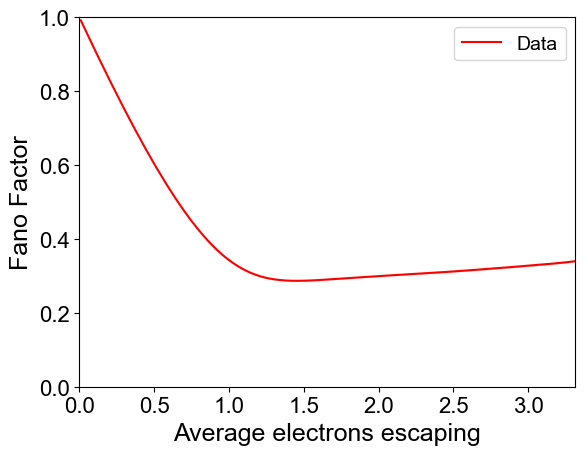

In [14]:
%matplotlib inline
fig, ax = plt.subplots()
plot_fano_with_error(counts_n, avg_e_max=None, use_electrons_escaping=True,
                         fig_ax=(fig,ax), color='r', label='Data',
                         n_trials=50, ci=0.95, rng=None)
plt.show()
%matplotlib widget

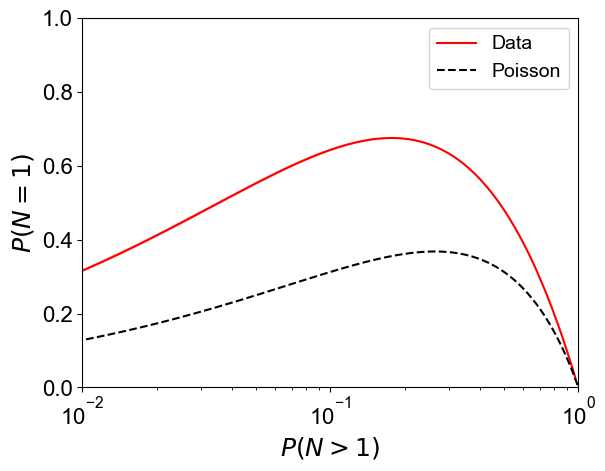

In [15]:
%matplotlib inline
fig, ax = plt.subplots()
plot_merit(counts_n, avg_e_max=None, fig_ax=(fig,ax), color='r', label='Data',
               show_poisson=True, xlim=[0.01,1], n_trials=50, ci=0.95,
               rng=None)
plt.show()
%matplotlib widget

## Plots

In [ ]:
gpt_plot_dist1d(screens[-1], 'kinetic_energy', nbins=50)

In [ ]:
gpt_plot_dist2d(screens[-1], 'x', 'y', nbins=50, axis='equal')

In [ ]:
def collect_trajectories(trajectories, initial):
    """Return {id: (t_array, pos_array (n,3), mom_array (n,3))} by following each
    particle's id across the list of per-time-snapshot ParticleGroups, starting
    from its initial state in `initial`."""
    by_id = {}
    for i, pid in enumerate(initial.id):
        by_id[pid] = (
            [initial.t[i]],
            [(initial.x[i], initial.y[i], initial.z[i])],
            [(initial.px[i], initial.py[i], initial.pz[i])],
        )
    for traj in trajectories:
        for i, pid in enumerate(traj.id):
            t_list, pos_list, mom_list = by_id.setdefault(pid, ([], [], []))
            if t_list and traj.t[i] == t_list[0]:
                continue  # snapshot landed exactly on the birth time already prepended
            t_list.append(traj.t[i])
            pos_list.append((traj.x[i], traj.y[i], traj.z[i]))
            mom_list.append((traj.px[i], traj.py[i], traj.pz[i]))
    return {
        pid: (np.array(t_list), np.array(pos_list), np.array(mom_list))
        for pid, (t_list, pos_list, mom_list) in by_id.items()
    }


by_id = collect_trajectories(trajectories, PG_run)
print(f"tracked {len(by_id)} particle trajectories")

In [ ]:
R = settings_copy['R_sphere']

fig, ax = plt.subplots(figsize=(6, 6))

z_plot_max = R * 2
r_plot_max = R * 2

ax.plot(r_bound * 1e9, z_bound * 1e9, color="0.6", lw=2)

for pid, (t, pos, mom) in by_id.items():
    ax.plot(np.sqrt(pos[:, 0]**2 + pos[:, 1]**2) * 1e9, pos[:, 2] * 1e9, lw=0.8, alpha=0.7)

ax.set_xlabel("r [nm]")
ax.set_ylabel("z [nm]")
ax.set_xlim(0, r_plot_max*1e9)
ax.set_ylim(-0.1*R*1e9, z_plot_max*1e9)
ax.set_aspect("equal")
plt.show()